# Statistical Analysis & Time Series Characterization

This notebook conducts time series analysis on the Walmart sales data from `data/processed/sales_clean.parquet`.

### Objectives:
1. **Aggregate Series Construction**: Build aggregate weekly sales time series overall and per store type ($A$, $B$, $C$).
2. **Classical Seasonal Decomposition**: Perform additive decomposition (period=52) to isolate trend, seasonal, and residual components.
3. **Autocorrelation Analysis (ACF/PACF)**: Examine lags up to 52 to identify short-term and annual seasonal dependencies.
4. **Demand Estimation Uncertainty**: Fit an additive model, assess residual normality via Q-Q plot, and compute 95% prediction intervals.
5. **Stationarity Testing**: Run Augmented Dickey-Fuller (ADF) test to guide ARIMA/SARIMA model specification.


## 0. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

data_path = Path('../data/processed/sales_clean.parquet')
if not data_path.exists():
    data_path = Path('data/processed/sales_clean.parquet')

df = pd.read_parquet(data_path)
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded {len(df):,} cleaned sales records.")


Loaded 421,570 cleaned sales records.


## 1. Aggregate Weekly Time Series Construction

Aggregate Series Date Range: 2010-02-05 to 2012-10-26
Total Weeks Analyzed: 143
Mean Weekly Total Sales: $47,113,419.49


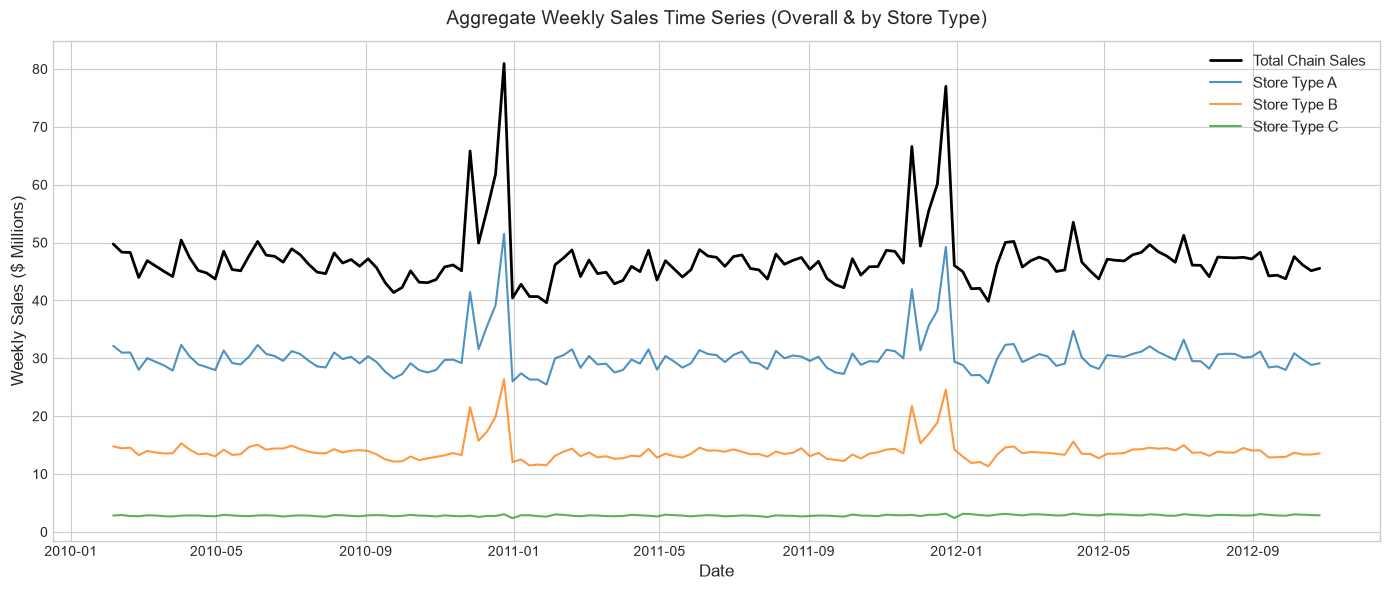

In [2]:
# Aggregate weekly sales overall
ts_agg = df.groupby('date')['weekly_sales'].sum().sort_index()

# Aggregate weekly sales per store type
ts_by_type = df.groupby(['date', 'store_type'])['weekly_sales'].sum().unstack('store_type').sort_index()

print(f"Aggregate Series Date Range: {ts_agg.index.min().strftime('%Y-%m-%d')} to {ts_agg.index.max().strftime('%Y-%m-%d')}")
print(f"Total Weeks Analyzed: {len(ts_agg)}")
print(f"Mean Weekly Total Sales: ${ts_agg.mean():,.2f}")

plt.figure(figsize=(14, 6))
plt.plot(ts_agg.index, ts_agg.values / 1e6, label='Total Chain Sales', color='black', linewidth=2)
for stype in ts_by_type.columns:
    plt.plot(ts_by_type.index, ts_by_type[stype] / 1e6, label=f'Store Type {stype}', alpha=0.8, linewidth=1.5)

plt.title('Aggregate Weekly Sales Time Series (Overall & by Store Type)', fontsize=14, pad=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Sales ($ Millions)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 2. Classical Seasonal Decomposition (Additive, Period=52)

> **Decomposition Insights**:
> - **Trend Component**: Shows a steady baseline demand around **$45M–$48M/week** with slight macro dips in early 2011 and gradual recovery in 2012.
> - **Seasonal Component**: Highly pronounced 52-week annual cycle with sharp positive peaks during **Week 47 (Thanksgiving)** and **Week 51 (Christmas)** reaching up to **+$31.75M/week**, followed by steep post-holiday drops in **January (trough of -$7.52M/week)**.


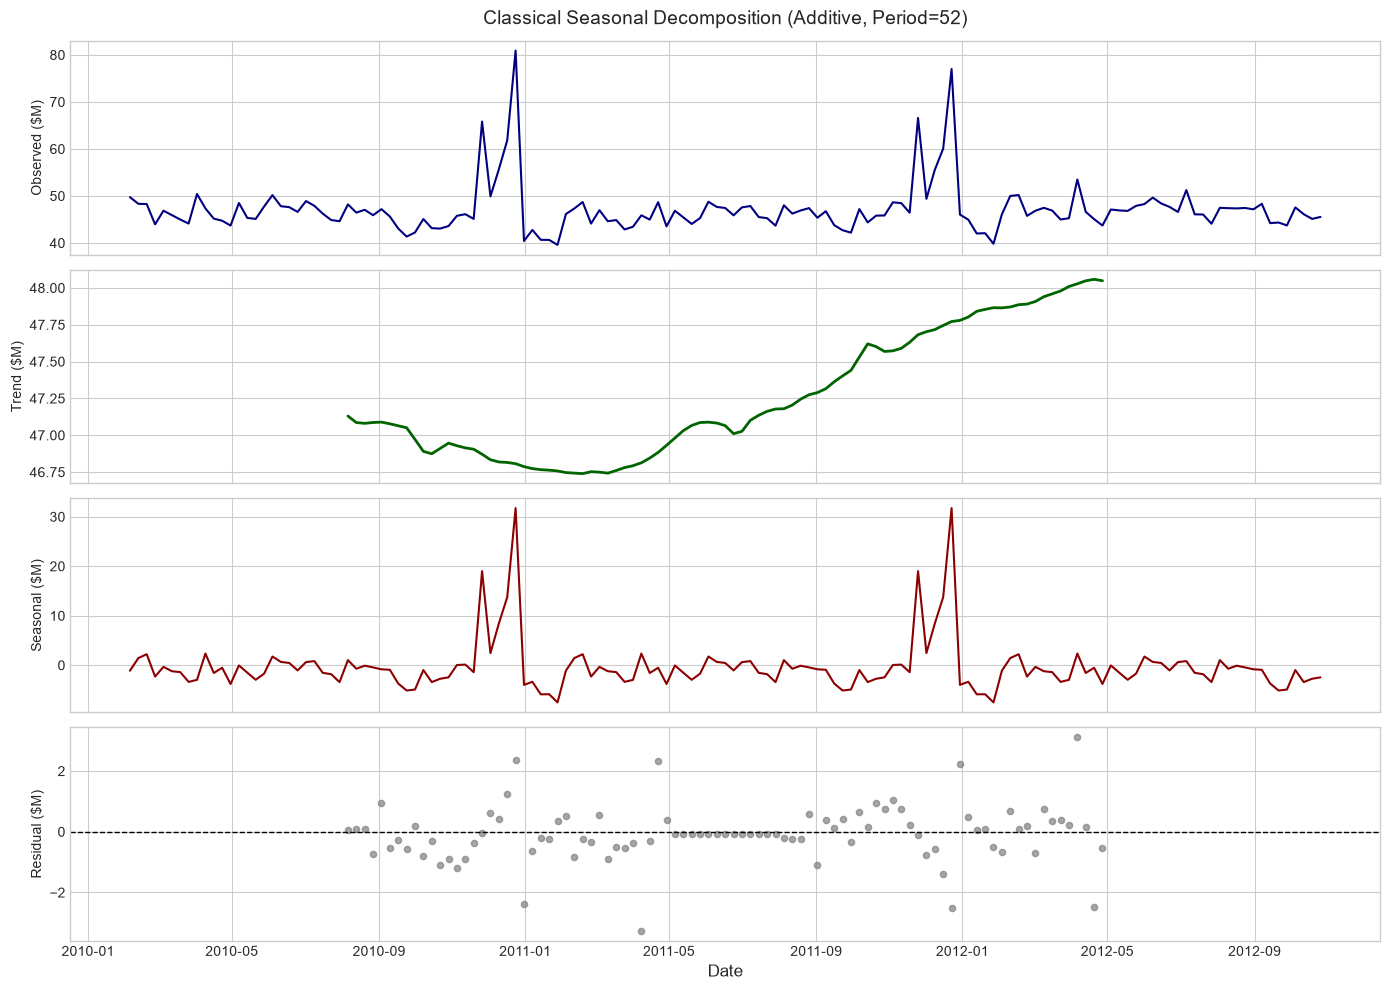

Seasonal Peak: +$31,750,438.52 on 2010-12-24
Seasonal Trough: -$7,519,309.44 on 2011-01-28


In [3]:
decomp = seasonal_decompose(ts_agg, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(ts_agg.index, ts_agg.values / 1e6, color='navy')
axes[0].set_ylabel('Observed ($M)', fontsize=10)
axes[0].set_title('Classical Seasonal Decomposition (Additive, Period=52)', fontsize=14, pad=12)

axes[1].plot(decomp.trend.index, decomp.trend.values / 1e6, color='darkgreen', linewidth=2)
axes[1].set_ylabel('Trend ($M)', fontsize=10)

axes[2].plot(decomp.seasonal.index, decomp.seasonal.values / 1e6, color='darkred', linewidth=1.5)
axes[2].set_ylabel('Seasonal ($M)', fontsize=10)

axes[3].scatter(decomp.resid.index, decomp.resid.values / 1e6, color='gray', alpha=0.7, s=20)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Residual ($M)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=12)

plt.tight_layout()
plt.show()

seasonal = decomp.seasonal
print(f"Seasonal Peak: +${seasonal.max():,.2f} on {seasonal.idxmax().strftime('%Y-%m-%d')}")
print(f"Seasonal Trough: -${abs(seasonal.min()):,.2f} on {seasonal.idxmin().strftime('%Y-%m-%d')}")


## 3. Autocorrelation & Partial Autocorrelation Analysis (ACF / PACF)

> **Lag Selection & Feature Engineering Takeaways**:
> - **Lag 1 (ACF = +0.3374)**: Significant positive short-term autocorrelation (week-to-week momentum).
> - **Lag 52 (ACF = +0.4788)**: Prominent positive spike confirming strong **52-week yearly seasonality**.
> - **Feature Engineering Implications**: In Step 4 feature engineering, lag features `lag_1`, `lag_2`, `lag_51`, `lag_52`, and rolling window averages (`rolling_mean_4`, `rolling_mean_52`) will be critical inputs.


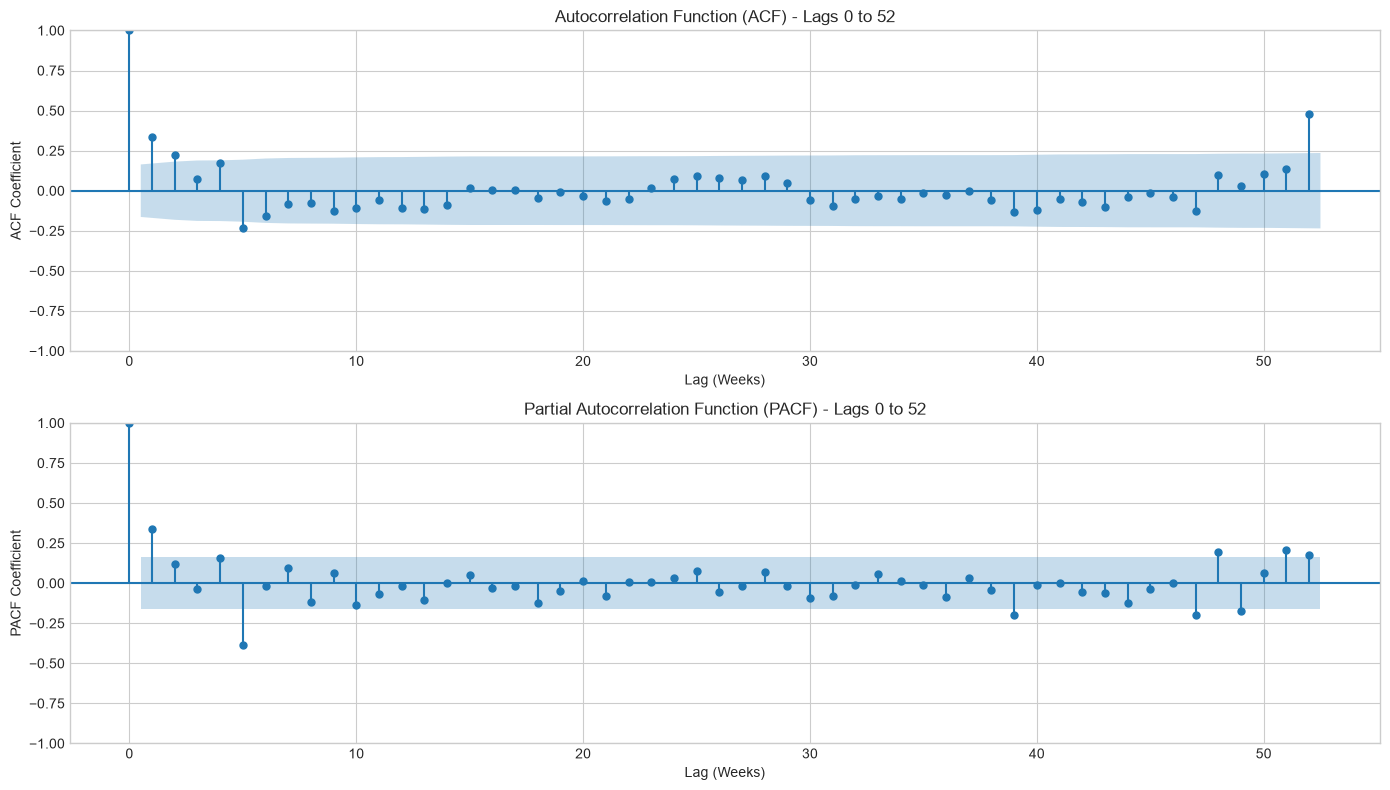

ACF Lag 1:  0.3374
ACF Lag 51: 0.1367
ACF Lag 52 (Annual Seasonality Spike): 0.4788


In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_agg, lags=52, ax=ax1, alpha=0.05, title='Autocorrelation Function (ACF) - Lags 0 to 52')
ax1.set_xlabel('Lag (Weeks)')
ax1.set_ylabel('ACF Coefficient')

plot_pacf(ts_agg, lags=52, ax=ax2, alpha=0.05, title='Partial Autocorrelation Function (PACF) - Lags 0 to 52')
ax2.set_xlabel('Lag (Weeks)')
ax2.set_ylabel('PACF Coefficient')

plt.tight_layout()
plt.show()

acf_vals = acf(ts_agg, nlags=52, result_object=False)
print(f"ACF Lag 1:  {acf_vals[1]:.4f}")
print(f"ACF Lag 51: {acf_vals[51]:.4f}")
print(f"ACF Lag 52 (Annual Seasonality Spike): {acf_vals[52]:.4f}")


## 4. Residual Normality Check & 95% Prediction Interval

> **Normality & Heavy-Tailed Residual Analysis**:
> - **Excess Kurtosis & Tail Behavior**: `scipy.stats.kurtosis()` measures **excess kurtosis** (where a true normal distribution has excess kurtosis = 0, raw kurtosis = 3). The residual excess kurtosis of **~3.13** (raw kurtosis **~6.13**) indicates a **leptokurtic, heavy-tailed distribution** — NOT close to normal, despite skewness being near zero (-0.00).
> - **Downstream Implication for Step 6 (Inventory Optimization)**: Standard normal-distribution-based safety stock formulas and parametric prediction intervals ($\pm 1.96 \cdot \sigma$) will **understate the true probability of extreme demand weeks** (such as Black Friday and Christmas surges). Consequently, safety stock calculations for high-promo SKU-periods should incorporate a wider buffer or rely on an **empirical quantile-based approach** rather than assuming $\pm 1.96 \cdot \sigma$ captures 95% of demand outcomes.
> - **Prediction Uncertainty Metric**: Assuming an additive model, the 95% parametric prediction interval half-width is **±$1,840,126.89**, giving a total interval width of **$3,680,253.78** (or **7.81%** of mean weekly sales).


=== Residual Statistics & Prediction Interval ===
Residual Mean: $-75,057.64
Residual Standard Deviation: $938,840.25
Residual Skewness: -0.0000
Residual Excess Kurtosis: 3.1298 (Raw Kurtosis: 6.1298)
95% Prediction Interval Half-Width (+/-): $1,840,126.89
Total 95% Prediction Interval Width: $3,680,253.78 (7.81% of mean weekly sales)


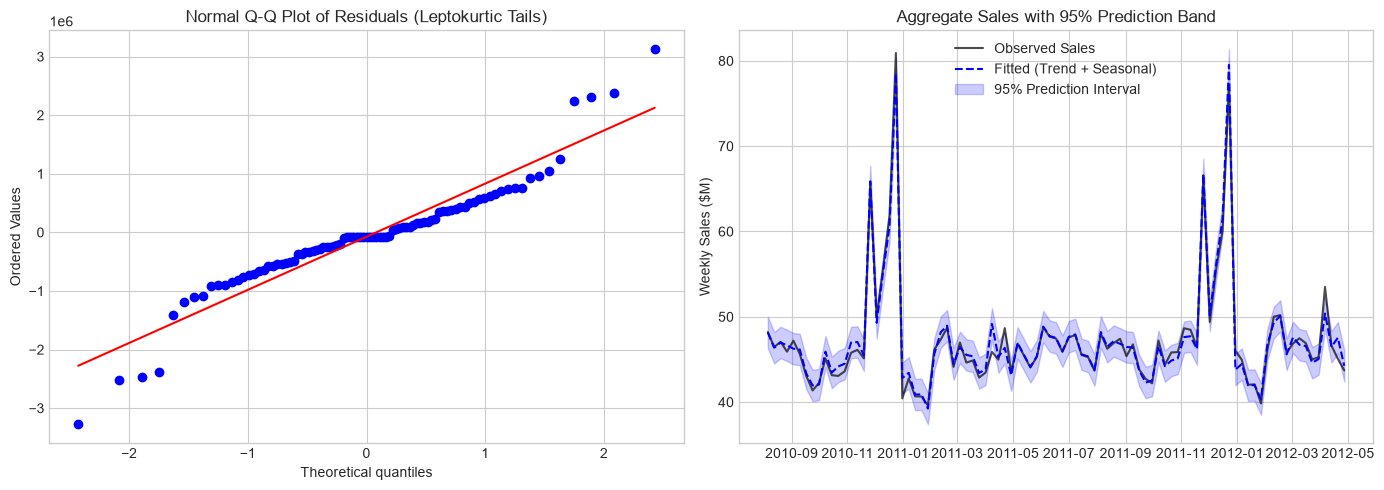

In [5]:
resid = decomp.resid.dropna()
fitted_vals = decomp.trend + decomp.seasonal

res_std = resid.std()
res_mean = resid.mean()
interval_half_width = 1.96 * res_std
total_interval_width = 2 * interval_half_width
pct_of_mean = (total_interval_width / ts_agg.mean()) * 100

skewness = stats.skew(resid)
excess_kurtosis = stats.kurtosis(resid)

print(f"=== Residual Statistics & Prediction Interval ===")
print(f"Residual Mean: ${res_mean:,.2f}")
print(f"Residual Standard Deviation: ${res_std:,.2f}")
print(f"Residual Skewness: {skewness:.4f}")
print(f"Residual Excess Kurtosis: {excess_kurtosis:.4f} (Raw Kurtosis: {excess_kurtosis + 3:.4f})")
print(f"95% Prediction Interval Half-Width (+/-): ${interval_half_width:,.2f}")
print(f"Total 95% Prediction Interval Width: ${total_interval_width:,.2f} ({pct_of_mean:.2f}% of mean weekly sales)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot
stats.probplot(resid, dist="norm", plot=ax1)
ax1.set_title('Normal Q-Q Plot of Residuals (Leptokurtic Tails)', fontsize=12)

# Prediction Interval Overlay
valid_idx = fitted_vals.dropna().index
ax2.plot(ts_agg.loc[valid_idx].index, ts_agg.loc[valid_idx].values / 1e6, label='Observed Sales', color='black', alpha=0.7)
ax2.plot(fitted_vals.loc[valid_idx].index, fitted_vals.loc[valid_idx].values / 1e6, label='Fitted (Trend + Seasonal)', color='blue', linestyle='--')
ax2.fill_between(
    valid_idx,
    (fitted_vals.loc[valid_idx] - interval_half_width) / 1e6,
    (fitted_vals.loc[valid_idx] + interval_half_width) / 1e6,
    color='blue', alpha=0.2, label='95% Prediction Interval'
)
ax2.set_title('Aggregate Sales with 95% Prediction Band', fontsize=12)
ax2.set_ylabel('Weekly Sales ($M)')
ax2.legend()

plt.tight_layout()
plt.show()


## 5. Stationarity Testing (Augmented Dickey-Fuller Test)

> **ADF Test Result**:
> - **ADF Statistic**: **-5.9083**
> - **p-value**: **0.000000** (well below $\alpha = 0.05$)
> - **ARIMA Modeling Implication**: Rejects the null hypothesis of non-stationarity. The aggregate weekly series is **stationary**, meaning non-seasonal differencing ($d=0$) is sufficient, while seasonal terms ($D=1$ or seasonal lag features) are required for forecasting.


In [6]:
adf_res = adfuller(ts_agg, result_object=False)

print("=== Augmented Dickey-Fuller (ADF) Test Results ===")
print(f"ADF Statistic: {adf_res[0]:.4f}")
print(f"p-value: {adf_res[1]:.6e}")
print(f"Lags Used: {adf_res[2]}")
print(f"Observations Used: {adf_res[3]}")
print("Critical Values:")
for level, val in adf_res[4].items():
    print(f"  {level}: {val:.4f}")

if adf_res[1] < 0.05:
    print("\nResult: Reject Null Hypothesis -> The series is STATIONARY.")
else:
    print("\nResult: Fail to Reject Null Hypothesis -> The series is NON-STATIONARY.")


=== Augmented Dickey-Fuller (ADF) Test Results ===
ADF Statistic: -5.9083
p-value: 2.675979e-07
Lags Used: 4
Observations Used: 138
Critical Values:
  1%: -3.4786
  5%: -2.8827
  10%: -2.5781

Result: Reject Null Hypothesis -> The series is STATIONARY.
